In [421]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

athletes = pd.read_csv("athlete_events.csv")
regions = pd.read_csv("noc_regions.csv")
iconic=pd.read_csv("iconic_sport_per_country.csv")

filename = "110cultural.zip"
world = gpd.read_file(filename, layer="ne_110m_admin_0_countries")
world = world[['ISO_A3', 'SOVEREIGNT', 'CONTINENT', 'geometry']]
world = world.rename(columns={'SOVEREIGNT': 'Country'})

In [422]:
print(regions.columns.tolist())
print(regions.head())

['NOC', 'region', 'notes']
   NOC       region                 notes
0  AFG  Afghanistan                   NaN
1  AHO      Curacao  Netherlands Antilles
2  ALB      Albania                   NaN
3  ALG      Algeria                   NaN
4  AND      Andorra                   NaN


In [423]:
world["country_norm"] = world["Country"].astype(str).str.lower().str.strip()
world_names = world[["country_norm", "ISO_A3"]].drop_duplicates()

regions["region_norm"] = regions["region"].astype(str).str.lower().str.strip()

world_names = world_names.rename(columns={"country_norm": "region_norm"})

merged = regions.merge(world_names, on="region_norm", how="left")

missing = merged[merged["ISO_A3"].isna()][["NOC", "region"]]
print("Number of missing:", len(missing))
print(missing)

Number of missing: 59
     NOC                       region
1    AHO                      Curacao
4    AND                      Andorra
6    ANT                      Antigua
10   ARU                        Aruba
11   ASA               American Samoa
15   BAH                      Bahamas
17   BAR                     Barbados
21   BER                      Bermuda
26   BOH               Czech Republic
27   BOL                       Boliva
30   BRN                      Bahrain
37   CAY               Cayman Islands
38   CGO            Republic of Congo
45   COK                 Cook Islands
47   COM                      Comoros
48   CPV                   Cape Verde
54   CZE               Czech Republic
58   DMA                     Dominica
74   FSM                   Micronesia
77   GBR                           UK
85   GRN                      Grenada
88   GUM                         Guam
96   IOA  Individual Olympic Athletes
103  ISV           Virgin Islands, US
105  IVB      Virgin Islands

In [424]:
manual_iso = {
    "curacao": "CUW",
    "andorra": "AND",
    "antigua": "ATG",
    "aruba": "ABW",
    "american samoa": "ASM",
    "bahamas": "BHS",
    "barbados": "BRB",
    "bermuda": "BMU",
    
    "czech republic": "CZE",
    "boliva": "BOL",
    "bahrain": "BHR",
    "cayman islands": "CYM",
    "republic of congo": "COG",
    "cook islands": "COK",
    "comoros": "COM",
    "cape verde": "CPV", 
    "dominica": "DMA",
    
    "micronesia": "FSM",
    "grenada": "GRD",
    "guam": "GUM",
    
    "uk": "GBR",  
    "great britain": "GBR",

    "individual olympic athletes": None,
    "refugee olympic athletes": None,
    "saint vincent": "VCT",
    "trinidad": "TTO",
    "serbia": "SRB",
    "yugoslavia": "SRB",  
    "usa": "USA",
    "united states virgin islands": "VIR",
    "macedonia": "MKD",
    "monaco": "MCO",
    "mauritius": "MUS",
    "puerto rico": "PRI",
    "singapore": "SGP",
    "tanzania": "TZA",
    "tonga": "TON",
}

merged["ISO_A3"] = merged.apply(
    lambda row: manual_iso[row["region_norm"]] 
                if pd.isna(row["ISO_A3"]) and row["region_norm"] in manual_iso 
                else row["ISO_A3"],
    axis=1
)

world_final = world.merge(
    merged[["NOC", "ISO_A3"]],
    on="ISO_A3",
    how="left"
)

In [425]:
print("Merged columns:", merged.columns.tolist())

Merged columns: ['NOC', 'region', 'notes', 'region_norm', 'ISO_A3']


In [426]:
iconic_iso = iconic.merge(merged[["NOC", "ISO_A3"]].drop_duplicates(), on="NOC", how="left")
miss_iso = iconic_iso[iconic_iso["ISO_A3"].isna()][["NOC", "Team", "Sport"]]
print("Countries in iconic file missing ISO_A3 (should be small or zero):")
print(miss_iso)

Countries in iconic file missing ISO_A3 (should be small or zero):
     NOC                          Team     Sport
63   IOA   Individual Olympic Athletes  Shooting
70   ISV  United States Virgin Islands   Sailing
117  SGP                     Singapore  Swimming


In [427]:
iconic_iso = iconic.merge(merged[["NOC", "ISO_A3"]].drop_duplicates(), on="NOC", how="left")

strength = {"Weightlifting", "Wrestling", "Judo", "Boxing", "Taekwondo"}
endurance = {"Marathon", "Athletics Men's Marathon", "Rowing", "Canoe Sprint", "Cycling Road", "Triathlon"}
speed = {"Swimming", "Athletics", "Gymnastics", "Fencing", "Sprinting", "Cycling Track"}
precision = {"Shooting", "Archery", "Table Tennis", "Badminton", "Tennis", "Equestrian", "Sailing"}
team_sports = {"Football", "Basketball", "Volleyball", "Handball", "Water Polo", "Baseball/Softball", "Hockey"}

def sport_to_group(s):
    if pd.isna(s):
        return None
    s_low = s.lower()
    if any(k.lower() in s_low for k in ["weight", "judo", "wrestl", "box", "taekwondo"]):
        return "Strength/Power"
    if any(k in s_low for k in ["marathon", "row", "canoe", "cycling", "triathlon"]):
        return "Endurance"
    if any(k in s_low for k in ["swim", "gymnast", "fenc", "sprint", "athletics"]):
        return "Speed/Technical"
    if any(k in s_low for k in ["shoot", "archer", "table tennis", "badminton", "tennis", "equestrian", "sail"]):
        return "Precision/Skill"
    if any(k in s_low for k in ["football", "basket", "volley", "handball", "water polo", "baseball", "soccer", "hockey"]):
        return "Team/Ball Sports"
    return "Other"

iconic_iso["Sport_group"] = iconic_iso["Sport"].apply(sport_to_group)
world_iconic = world.merge(iconic_iso[["ISO_A3", "Sport", "Sport_group"]], on="ISO_A3", how="left")

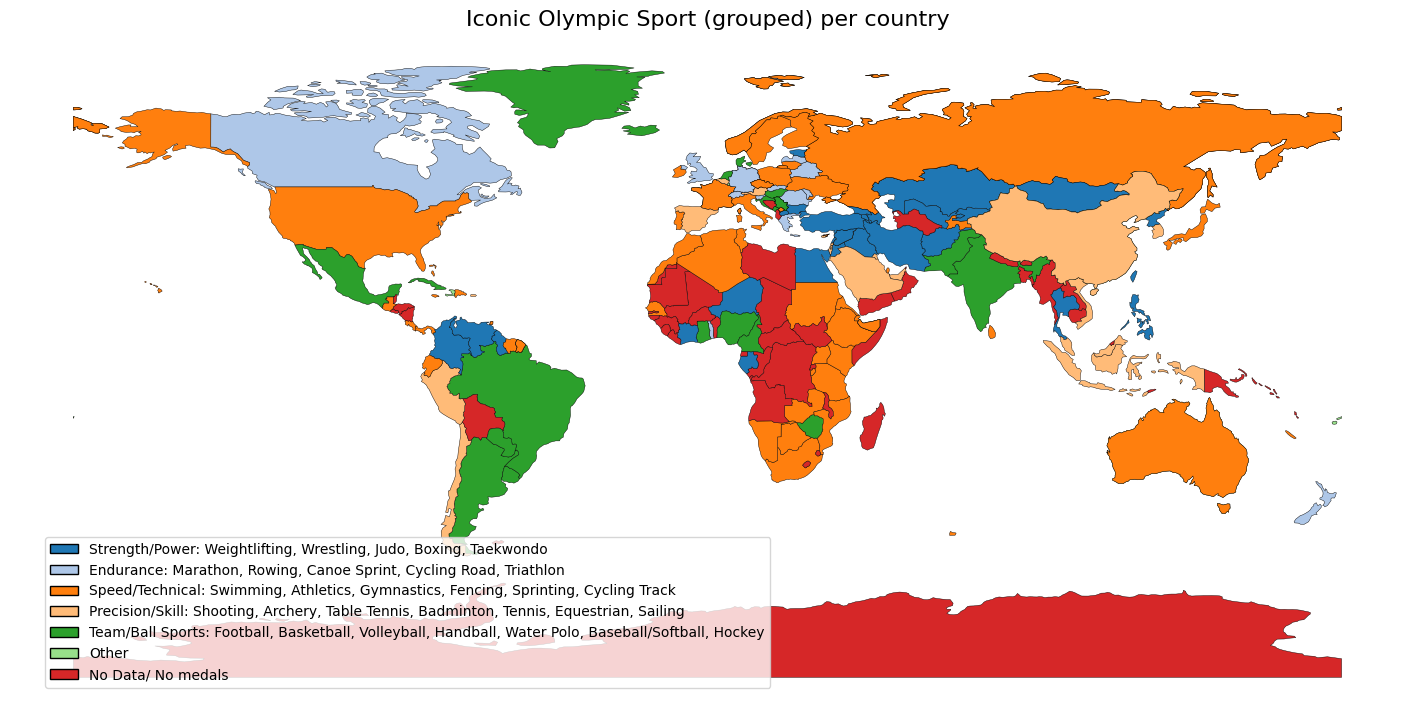

In [428]:
plot_col = "Sport_group"

legend_details = {
    "Strength/Power": "Strength/Power: Weightlifting, Wrestling, Judo, Boxing, Taekwondo",
    "Endurance": "Endurance: Marathon, Rowing, Canoe Sprint, Cycling Road, Triathlon",
    "Speed/Technical": "Speed/Technical: Swimming, Athletics, Gymnastics, Fencing, Sprinting, Cycling Track",
    "Precision/Skill": "Precision/Skill: Shooting, Archery, Table Tennis, Badminton, Tennis, Equestrian, Sailing",
    "Team/Ball Sports": "Team/Ball Sports: Football, Basketball, Volleyball, Handball, Water Polo, Baseball/Softball, Hockey",
    "Other": "Other",
    "No Data/ No medals": "No Data/ No medals"
}

groups = world_iconic[plot_col].fillna("No Data/ No medals").unique().tolist()
groups_sorted = [
    "Strength/Power",
    "Endurance",
    "Speed/Technical",
    "Precision/Skill",
    "Team/Ball Sports",
    "Other",
    "No Data/ No medals"
]

groups_sorted = [g for g in groups_sorted if g in groups]
cmap = plt.get_cmap("tab20")
colors = {g: cmap(i % 20) for i, g in enumerate(groups_sorted)}
world_iconic["color"] = world_iconic[plot_col].fillna("No Data/ No medals").map(colors)

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

world_iconic.plot(
    ax=ax,
    color=world_iconic["color"],
    edgecolor="black",
    linewidth=0.3
)

legend_patches = [
    Patch(facecolor=colors[g], edgecolor="k", label=legend_details[g])
    for g in groups_sorted
]

ax.set_title("Iconic Olympic Sport (grouped) per country", fontsize=16)
ax.axis("off")
ax.legend(handles=legend_patches, loc="lower left", bbox_to_anchor=(0.02, 0.02))
plt.show()


In [429]:
summer = athletes[athletes["Season"] == "Summer"]
medals = summer[summer["Medal"].notna()]
medals_iso = medals.merge(
    merged[["NOC", "ISO_A3"]],
    on="NOC",
    how="left"
)

countries_with_medals = medals_iso["ISO_A3"].nunique()
countries_participated = summer.merge(
    merged[["NOC", "ISO_A3"]],
    on="NOC",
    how="left"
)["ISO_A3"].nunique()

countries_with_medals, countries_participated

(134, 188)

In [430]:
summer_medals = athletes[
    (athletes["Season"] == "Summer") &
    (athletes["Medal"].notna())
]
sports_2016 = (
    summer_medals[summer_medals["Year"] == 2016]["Sport"]
    .unique()
)

summer_medals = summer_medals[
    summer_medals["Sport"].isin(sports_2016)
]
summer_medals = summer_medals.merge(
    merged[["NOC", "ISO_A3"]],
    on="NOC",
    how="left"
)
sport_summary = (
    summer_medals
    .groupby("Sport")
    .agg(
        total_medals=("ISO_A3", "count"),
        num_countries=("ISO_A3", "nunique")
    )
    .reset_index()
    .sort_values("num_countries", ascending=False)
)

top5_most = sport_summary.head(5)
top5_least = sport_summary.tail(5)
top5_most, top5_least

(            Sport  total_medals  num_countries
 1       Athletics          4208             92
 5          Boxing          1006             74
 32  Weightlifting           680             61
 22       Shooting          1388             59
 33      Wrestling          1343             57,
                     Sport  total_medals  num_countries
 4        Beach Volleyball            72             11
 28           Trampolining            30              9
 24  Synchronized Swimming           219              9
 12                   Golf            46              7
 20           Rugby Sevens            74              6)

In [431]:
def prepare_stack_percent(df, sports, top_n=6):
    tmp = df[df["Sport"].isin(sports)].copy()
    tmp = tmp[tmp["ISO_A3"] != "-99"]
    stack = (
        tmp
        .groupby(["Sport", "ISO_A3"])
        .size()
        .reset_index(name="medals")
    )

    total = stack.groupby("Sport")["medals"].sum().reset_index(name="total")
    stack = stack.merge(total, on="Sport")
    stack["rank"] = (
        stack
        .sort_values(["Sport", "medals"], ascending=[True, False])
        .groupby("Sport")
        .cumcount()
    )

    # assign country or OTHER
    stack["Country"] = stack.apply(
        lambda x: x["ISO_A3"] if x["rank"] < top_n else "OTHER",
        axis=1
    )

    # count how many countries fall into OTHER
    other_counts = (
        stack[stack["Country"] == "OTHER"]
        .groupby("Sport")["ISO_A3"]
        .nunique()
        .reset_index(name="other_countries")
    )

    stack = (
        stack
        .groupby(["Sport", "Country"])
        .agg(
            medals=("medals", "sum"),
            total=("total", "first")
        )
        .reset_index()
    )

    stack = stack.merge(other_counts, on="Sport", how="left")
    stack["other_countries"] = stack["other_countries"].fillna(0).astype(int)
    stack["percent"] = stack["medals"] / stack["total"] * 100

    order = (
        stack.groupby("Sport")["total"]
        .first()
        .sort_values(ascending=False)
        .index
    )

    return stack, order

    
stack_most, order_most = prepare_stack_percent(
    summer_medals,
    top5_most["Sport"],
    top_n=6
)

stack_least, order_least = prepare_stack_percent(
    summer_medals,
    top5_least["Sport"],
    top_n=6
)


In [432]:
def plot_stacked_bar_percent(stack, order, title, ymax):
    fig, ax = plt.subplots(figsize=(16, 7))

    bottom = {s: 0 for s in order}

    # precompute number of medal-winning countries per sport
    country_counts = (
        summer_medals
        .groupby("Sport")["ISO_A3"]
        .nunique()
    )

    for country in stack["Country"].unique():
        sub = stack[stack["Country"] == country]

        values = [
            sub[sub["Sport"] == s]["medals"].sum() if s in sub["Sport"].values else 0
            for s in order
        ]

        # stacked bars
        ax.bar(
            order,
            values,
            bottom=[bottom[s] for s in order],
            label=country,
            width=0.65,
        )

        # annotate segments
        for i, sport in enumerate(order):
            row = sub[sub["Sport"] == sport]
            if row.empty:
                continue

            pct = row.iloc[0]["percent"]

            # --- NEW RULE: OTHER labels simplified ---
            if country == "OTHER":
                if pct >= 5:
                    label = f"{row.iloc[0]['other_countries']} CTR {pct:.1f}%"
                else:
                    continue

            # --- Non-OTHER (countries) ---
            else:
                if pct >= 7:
                    label = f"{country} {pct:.1f}%"
                else:
                    continue

            ax.text(
                i,
                bottom[sport] + values[i] / 2,
                label,
                ha="center",
                va="center",
                fontsize=16
            )

        # update bottom for next country
        for i, sport in enumerate(order):
            bottom[sport] += values[i]

    # add total country count above bars
    for i, sport in enumerate(order):
        n_countries = country_counts.get(sport, 0)
        ax.text(
            i,
            bottom[sport] + ymax * 0.015,
            f"{n_countries} countries",
            ha="center",
            va="bottom",
            fontsize=16,
            fontweight="bold"
        )

    ax.set_title(title, fontsize=20)
    ax.set_ylabel("Total medals")
    ax.set_xlabel("Sport")
    ax.set_ylim(0, ymax)
    ax.tick_params(axis='x', rotation=25, labelsize=20)

    # clean legend (remove -99)
    handles, labels = ax.get_legend_handles_labels()
    clean = [(h, l) for h, l in zip(handles, labels) if l != "-99"]

    ax.legend(
        [h for h, _ in clean],
        [l for _, l in clean],
        title="Country (ISO)",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

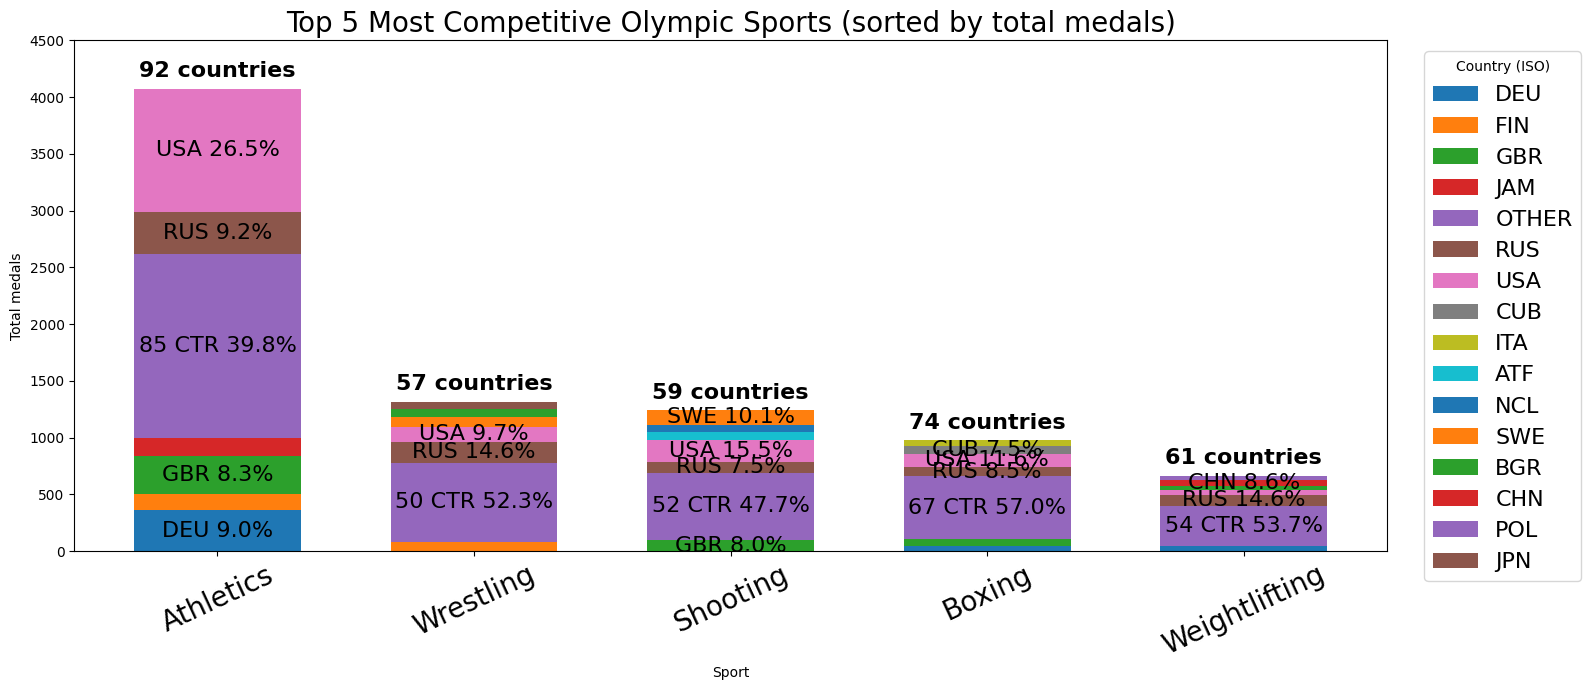

In [433]:
plot_stacked_bar_percent(
    stack_most,
    order_most,
    "Top 5 Most Competitive Olympic Sports (sorted by total medals)",
    ymax=4500,
)


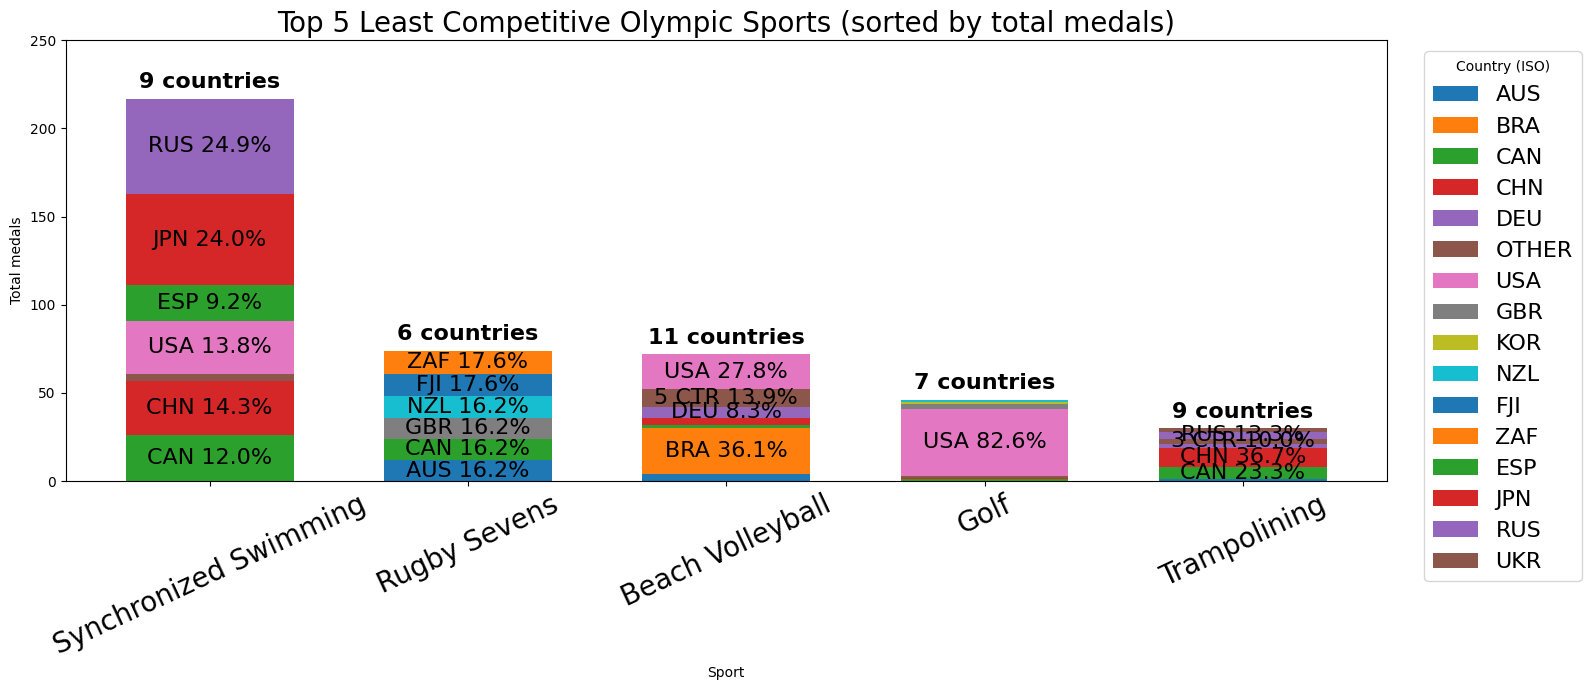

In [434]:
plot_stacked_bar_percent(
    stack_least,
    order_least,
    "Top 5 Least Competitive Olympic Sports (sorted by total medals)",
    ymax=250,
)

In [435]:
sport_totals = (
    summer_medals
    .groupby("Sport")["Medal"]
    .count()
    .rename("sport_total")
)

country_sport = (
    summer_medals
    .groupby(["ISO_A3", "Sport"])["Medal"]
    .count()
    .rename("medals")
    .reset_index()
)

country_sport = country_sport.merge(sport_totals, on="Sport", how="left")
country_sport["percent"] = (
    country_sport["medals"] / country_sport["sport_total"] * 100
)

top10_dom = (
    country_sport
    .sort_values("percent", ascending=False)
    .head(10)
)

top10_dom


,ISO_A3,Sport,medals,sport_total,percent
1015,USA,Golf,38,46,82.608696
265,CHN,Table Tennis,83,176,47.159091
874,RUS,Rhythmic Gymnastics,49,132,37.121212
268,CHN,Trampolining,11,30,36.666667
178,BRA,Beach Volleyball,26,72,36.111111
244,CHN,Badminton,64,180,35.555556
1023,USA,Swimming,1078,3229,33.384949
1011,USA,Diving,140,431,32.482599
1006,USA,Basketball,341,1156,29.498270
1007,USA,Beach Volleyball,20,72,27.777778


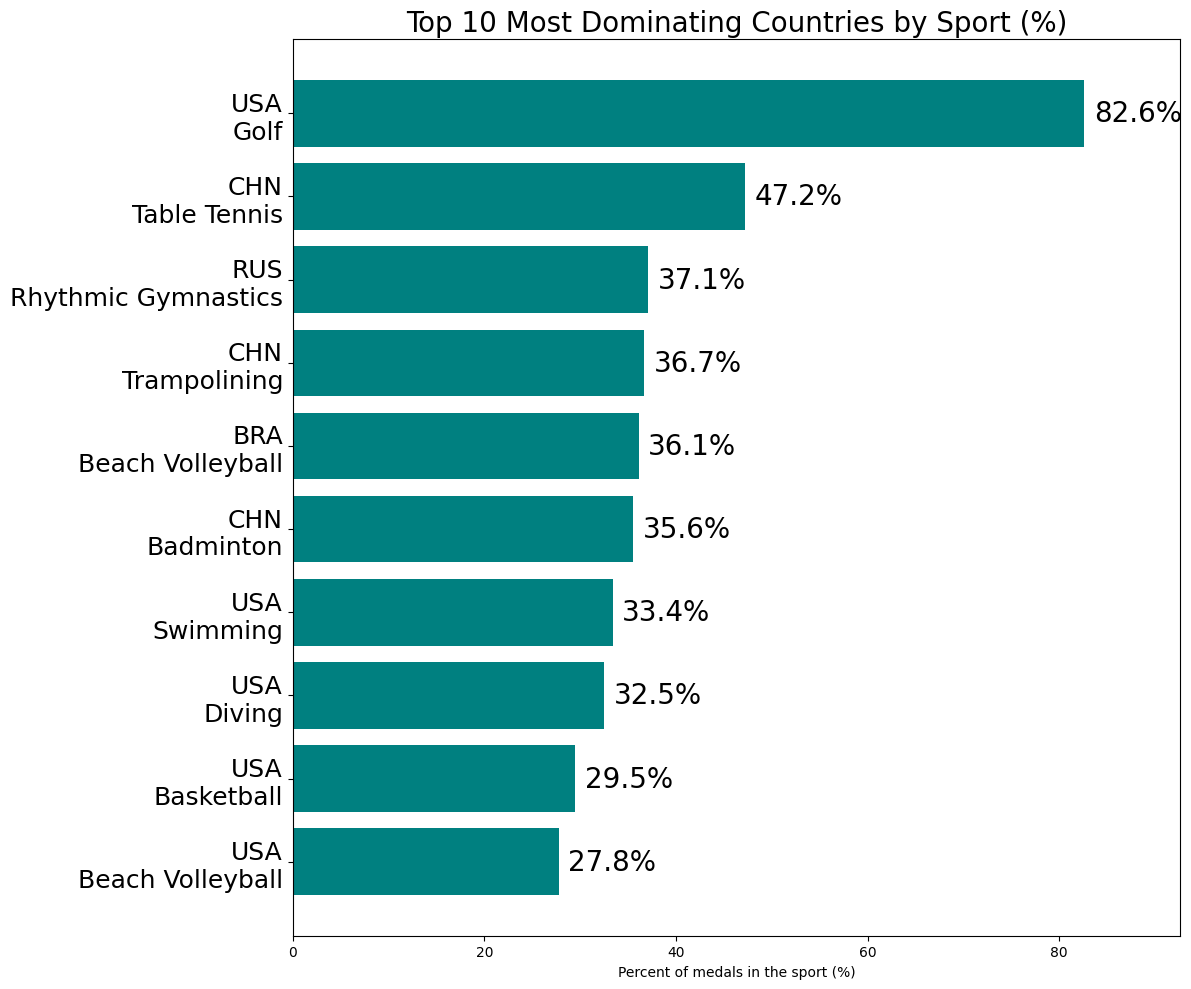

In [436]:
def plot_top10_domination(df):
    df = df.copy()
    df["label"] = df["ISO_A3"] + "\n" + df["Sport"]
    plt.figure(figsize=(12, 10))
    bars = plt.barh(
        df["label"],
        df["percent"],
        color="teal"
    )

    for bar, pct, medals in zip(bars, df["percent"], df["medals"]):
        plt.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%",
            va="center",
            fontsize=20
        )
        
    plt.tick_params(axis='y', labelsize=18)
    plt.xlabel("Percent of medals in the sport (%)")
    plt.title("Top 10 Most Dominating Countries by Sport (%)", fontsize=20)
    plt.xlim(0, df["percent"].max() + 10)
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

plot_top10_domination(top10_dom)


In [437]:
year_totals = (
    summer_medals
    .groupby("Year")["Medal"]
    .count()
    .rename("year_total")
)

country_year = (
    summer_medals
    .groupby(["Year", "ISO_A3"])["Medal"]
    .count()
    .rename("medals")
    .reset_index()
)

country_year = country_year.merge(year_totals, on="Year", how="left")
country_year["percent"] = country_year["medals"] / country_year["year_total"] * 100
country_year = country_year[country_year["ISO_A3"] != "-99"]

latest_year = 2016
top_2016 = (
    country_year[country_year["Year"] == latest_year]
    .sort_values("medals", ascending=False)
    .head(10)["ISO_A3"]
    .tolist()
)

country_year["CountryGroup"] = country_year["ISO_A3"].apply(
    lambda x: x if x in top_2016 else "OTHER"
)

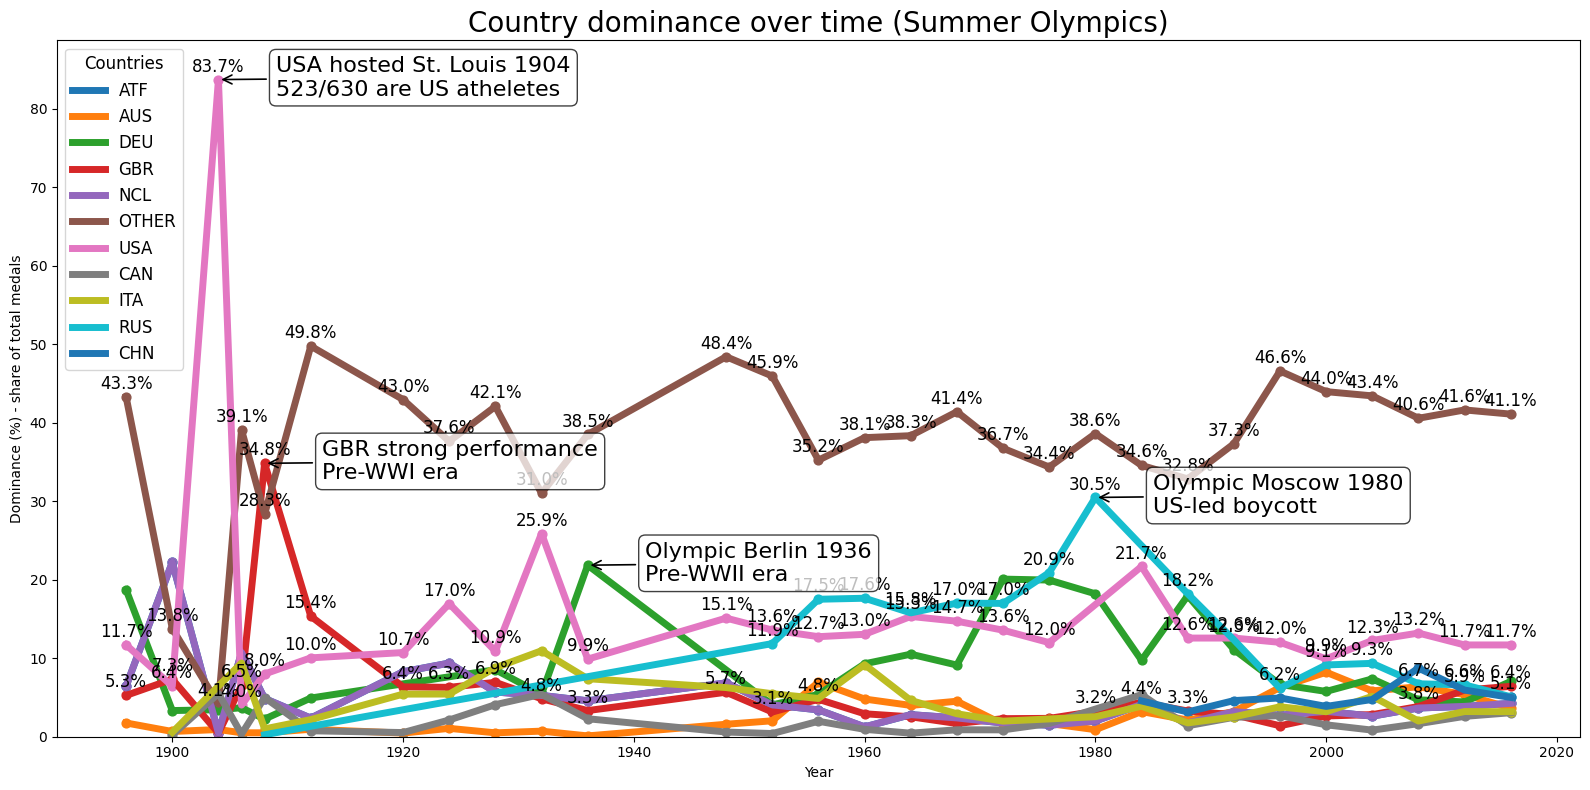

In [438]:
country_grouped = (
    country_year
    .groupby(["Year", "CountryGroup"])["percent"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(16, 8))
sns.lineplot(
    data=country_grouped,
    x="Year",
    y="percent",
    hue="CountryGroup",
    palette="tab10",
    linewidth=5
)

label_countries = ["USA", "OTHER", "GBR", "RUS"]

groups = country_grouped["CountryGroup"].unique()

for g in groups:
    sub = country_grouped[country_grouped["CountryGroup"] == g]

    plt.scatter(sub["Year"], sub["percent"], s=40)

    if g in label_countries:
        for _, row in sub.iterrows():
            pct = row["percent"]
            if pct >= 3:
                plt.text(
                    row["Year"],
                    pct + 0.5,
                    f"{pct:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=12
                )

peak_notes = {
    ("USA", 1904): "USA hosted St. Louis 1904\n523/630 are US atheletes",
    ("GBR", 1908): "GBR strong performance\nPre-WWI era",
    ("DEU", 1936): "Olympic Berlin 1936\nPre-WWII era",
    ("RUS", 1980): "Olympic Moscow 1980\nUS-led boycott"
}

for (country, year), text in peak_notes.items():
    row = country_grouped[
        (country_grouped["CountryGroup"] == country) &
        (country_grouped["Year"] == year)
    ]

    if not row.empty:
        x = row["Year"].values[0]
        y = row["percent"].values[0]

        plt.annotate(
            text,
            xy=(x, y),
            xytext=(x + 5, y - 2),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="black"),
            fontsize=16,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75)
        )

plt.title("Country dominance over time (Summer Olympics)", fontsize=20)
plt.xlabel("Year")
plt.ylabel("Dominance (%) - share of total medals")
plt.ylim(0, country_grouped["percent"].max() + 5)

plt.legend(
    title="Countries",
    fontsize=12,
    title_fontsize=12,
    loc="upper left"
)

plt.tight_layout()
plt.show()